## Setup

In [ ]:
pip install numpy

In [1]:
from google.colab import drive
# if you mount your drive somewhere else, change the path accordingly
drive.mount('/content/gdrive/')

import sys
#My Drive, change if needed
prefix = '/content/gdrive/My Drive/'
# modify "customized_path_to_your_homework" here to where you uploaded your homework
customized_path_to_your_homework = 'MachineLearning/Assignment1'
sys_path = prefix + customized_path_to_your_homework
sys.path.append(sys_path)

Mounted at /content/gdrive/


## XGBoost

Dataset: 709 MVP candidate-seasons across 48 seasons (1978–2025)
Features: ['ppg', 'rpg', 'apg', 'spg', 'bpg', 'topg', 'mpg', 'fg_percent', 'ft_percent', 'ts_pct', 'start_rate', 'trp_dbl', 'g']

── XGBoost Hyperparameter Tuning ──
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params:  {'max_depth': 3, 'n_estimators': 100}
Best CV RMSE: 0.2573

Test RMSE (2023–2025): 0.2308

── Per-Season MVP Predictions (XGBoost) ──
  2023  Predicted: Joel Embiid                  Actual MVP: Joel Embiid                  Rank: #1  ✓  ρ=0.833
         Top 3: ['Joel Embiid', 'Nikola Jokić', 'Luka Dončić']
         Player                        Actual Share  Pred Share
         Joel Embiid                         0.915       0.721
         Nikola Jokić                        0.674       0.603
         Luka Dončić                         0.010       0.588
         Shai Gilgeous-Alexander             0.046       0.408
         Jayson Tatum                        0.280       0.407

  2024

Text(0.5, 1.02, 'NBA MVP Prediction — XGBoost vs Ranking SVM')

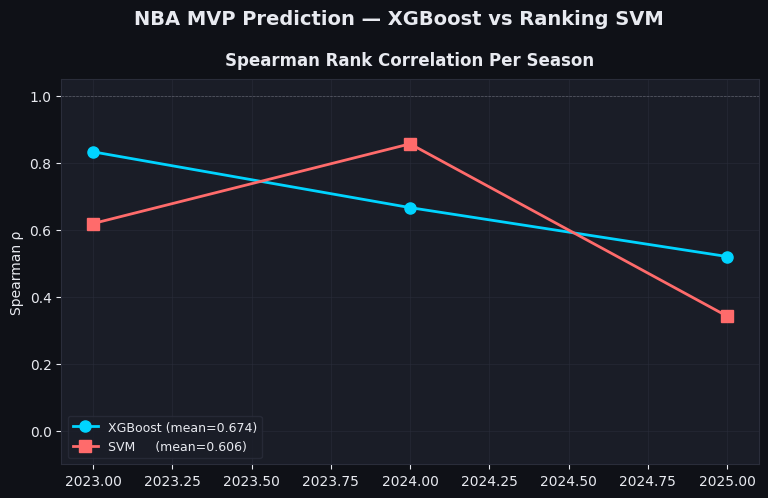

In [4]:
"""
NBA MVP Prediction with XGBoost
=================================
Labels: real MVP vote share from Player_Award_Shares.csv
Stats:  per-game features from Player_Totals.csv
Train: 2000–2022  |  Test: 2023–2025
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

#Load Data
awards = pd.read_csv("gdrive/MyDrive/MachineLearning/Project/Player Award Shares.csv")
mvp_votes = awards[awards["award"] == "nba mvp"][
    ["season", "player_id", "share", "winner"]
].copy()
stats = pd.read_csv("gdrive/MyDrive/MachineLearning/Project/Player Totals.csv")
stats = stats[stats["lg"] == "NBA"].copy()

# Handle traded players — keep season totals only
dup_mask = stats.duplicated(subset=["season", "player_id"], keep=False)
tot_mask = stats["team"] == "TOT"
stats = stats[~dup_mask | tot_mask].copy()

# Per-game features
stats["ppg"]        = stats["pts"] / stats["g"]
stats["rpg"]        = stats["trb"] / stats["g"]
stats["apg"]        = stats["ast"] / stats["g"]
stats["spg"]        = stats["stl"] / stats["g"]
stats["bpg"]        = stats["blk"] / stats["g"]
stats["topg"]       = stats["tov"] / stats["g"]
stats["mpg"]        = stats["mp"]  / stats["g"]
stats["ts_pct"]     = stats["pts"] / (2 * (stats["fga"] + 0.44 * stats["fta"]) + 1e-6)
stats["start_rate"] = stats["gs"]  / stats["g"]

feature_cols = [
    "ppg", "rpg", "apg", "spg", "bpg", "topg", "mpg",
    "fg_percent", "ft_percent", "ts_pct", "start_rate", "trp_dbl", "g"
]

# Merge award data with player stats
df = mvp_votes.merge(stats[["season", "player_id", "player"] + feature_cols],
                     on=["season", "player_id"], how="left")
df = df.dropna(subset=feature_cols).copy()

print(f"Dataset: {len(df)} MVP candidate-seasons across "
      f"{df['season'].nunique()} seasons ({df['season'].min()}–{df['season'].max()})")
print(f"Features: {feature_cols}\n")

#Train/Test Split
train = df[df["season"].between(2000, 2022)]
test  = df[df["season"].between(2023, 2025)]

X_train, y_train = train[feature_cols], train["share"]
X_test,  y_test  = test[feature_cols],  test["share"]

#Minimum Candidate Threshold
MIN_PPG = 20.0
MIN_MPG = 20.0
MIN_G   = 65

def apply_threshold(df_subset):
    return df_subset[
        (df_subset["ppg"] >= MIN_PPG) &
        (df_subset["mpg"] >= MIN_MPG) &
        (df_subset["g"]   >= MIN_G)
    ].copy()

#XGBoost with GridSearchCV - Claude assisted with outline framework, handling syntax, and helping debug/refine
print("── XGBoost Hyperparameter Tuning ──")
param_grid = {
    "max_depth":    [3, 4, 5, 6],
    "n_estimators": [100, 200, 300, 400],
}
base_model = XGBRegressor(
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_cv_rmse = -grid_search.best_score_
print(f"\nBest params:  {best_params}")
print(f"Best CV RMSE: {best_cv_rmse:.4f}\n")

#Train Final XGBoost with Best Params
model = XGBRegressor(
    **best_params,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
model.fit(X_train, y_train)

test_preds = model.predict(X_test)
test_rmse  = np.sqrt(np.mean((test_preds - y_test.values) ** 2))
print(f"Test RMSE (2023–2025): {test_rmse:.4f}\n")

#XGBoost Per-Season Predictions
print("── Per-Season MVP Predictions (XGBoost) ──")
top1_hits, top3_hits, total = 0, 0, 0
xgb_season_data = []

for season in sorted(test["season"].unique()):
    sdf = apply_threshold(test[test["season"] == season].copy())
    if sdf.empty:
        continue
    sdf["pred"] = model.predict(sdf[feature_cols])
    sdf = sdf.sort_values("pred", ascending=False).reset_index(drop=True)
    sdf["pred_rank"] = sdf.index + 1

    winner_row  = sdf[sdf["winner"] == True]
    actual_rank = int(winner_row["pred_rank"].values[0]) if len(winner_row) > 0 else None
    pred_name   = sdf.iloc[0]["player"]
    top3_names  = sdf.head(3)["player"].tolist()

    # Spearman rank correlation for this season
    sdf_ranked = sdf.copy()
    sdf_ranked["actual_rank"] = sdf_ranked["share"].rank(ascending=False)
    rho, _ = spearmanr(sdf_ranked["pred_rank"], sdf_ranked["actual_rank"])

    hit1 = actual_rank == 1
    hit3 = actual_rank is not None and actual_rank <= 3
    flag = "✓" if hit1 else ("~" if hit3 else "✗")
    if hit1: top1_hits += 1
    if hit3: top3_hits += 1
    total += 1

    xgb_season_data.append({
        "season":      season,
        "actual_rank": actual_rank,
        "hit1":        hit1,
        "hit3":        hit3,
        "spearman":    rho,
    })

    actual_name = winner_row["player"].values[0] if len(winner_row) > 0 else "?"
    print(f"  {season}  Predicted: {pred_name:<28} Actual MVP: {actual_name:<28} Rank: #{actual_rank}  {flag}  ρ={rho:.3f}")
    print(f"         Top 3: {top3_names}")
    print(f"         {'Player':<28} {'Actual Share':>13} {'Pred Share':>11}")
    for _, row in sdf.head(5).iterrows():
        print(f"         {row['player']:<28} {row['share']:>12.3f}  {row['pred']:>10.3f}")
    print()

mean_spearman_xgb = np.mean([d["spearman"] for d in xgb_season_data])
print(f"Top-1 Accuracy: {top1_hits/total:.0%}   Top-3 Accuracy: {top3_hits/total:.0%}   "
      f"Mean Spearman ρ: {mean_spearman_xgb:.3f}   ({total} seasons)\n")

#Feature Importances
print("── Feature Importances (XGBoost) ──")
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
for feat, val in imp.items():
    bar = "█" * int(val * 80)
    print(f"  {feat:<15} {val:.4f}  {bar}")

#2026 XGBoost Predictions
s26 = apply_threshold(stats[stats["season"] == 2026].dropna(subset=feature_cols).copy())
s26["pred"] = model.predict(s26[feature_cols])
top5 = s26.sort_values("pred", ascending=False).head(5)
print("\n── 2026 MVP Race (XGBoost) ──")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  #{i}  {row['player']:<28}  pred_share={row['pred']:.3f}"
          f"  ({row['ppg']:.1f}pts / {row['rpg']:.1f}reb / {row['apg']:.1f}ast)")

#Ranking SVM - Claude assisted with outline framework, handling syntax, and helping debug/refine
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

def build_pairwise_dataset(X_scaled, df_subset):
    X_pairs, y_pairs = [], []
    df_filtered = df_subset[df_subset["share"] >= 0.05].reset_index(drop=True)

    for season in df_filtered["season"].unique():
        mask   = (df_filtered["season"] == season).values
        idx    = np.where(mask)[0]
        shares = df_filtered["share"].values[idx]

        X_season = X_scaled[df_filtered[df_filtered["season"] == season].index]
        X_season = (X_season - X_season.mean(axis=0)) / (X_season.std(axis=0) + 1e-8)

        for a in range(len(idx)):
            for b in range(a + 1, len(idx)):
                if shares[a] == shares[b]:
                    continue
                i, j = (a, b) if shares[a] > shares[b] else (b, a)
                diff = X_season[i] - X_season[j]
                X_pairs.append(diff);  y_pairs.append(1)
                X_pairs.append(-diff); y_pairs.append(-1)

    return np.array(X_pairs), np.array(y_pairs)

print("\n── Ranking SVM — Hyperparameter Tuning ──")
X_pairs_train, y_pairs_train = build_pairwise_dataset(
    X_train_scaled, train.reset_index(drop=True)
)
print(f"  Pairwise training examples: {len(X_pairs_train):,}")

svm_param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}
svm_base = LinearSVC(max_iter=5000, random_state=42)
svm_grid = GridSearchCV(
    svm_base,
    svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_pairs_train, y_pairs_train)
best_C = svm_grid.best_params_["C"]
print(f"\n  Best C: {best_C}   CV Accuracy: {svm_grid.best_score_:.4f}\n")

svm = LinearSVC(C=best_C, max_iter=5000, random_state=42)
svm.fit(X_pairs_train, y_pairs_train)

# SVM Per-Season Predictions
print("── Ranking SVM Per-Season Predictions ──")
top1_hits_svm, top3_hits_svm, total_svm = 0, 0, 0
svm_season_data = []

test_svm = test.reset_index(drop=True).copy()

svm_scores = []
for season in sorted(test_svm["season"].unique()):
    mask         = (test_svm["season"] == season).values
    X_season     = X_test_scaled[mask]
    X_season_norm = (X_season - X_season.mean(axis=0)) / (X_season.std(axis=0) + 1e-8)
    svm_scores.extend(X_season_norm @ svm.coef_[0])
test_svm["svm_score"] = svm_scores

for season in sorted(test_svm["season"].unique()):
    sdf = apply_threshold(test_svm[test_svm["season"] == season].copy())
    if sdf.empty:
        continue
    sdf = sdf.sort_values("svm_score", ascending=False).reset_index(drop=True)
    sdf["pred_rank"] = sdf.index + 1

    winner_row  = sdf[sdf["winner"] == True]
    actual_rank = int(winner_row["pred_rank"].values[0]) if len(winner_row) > 0 else None
    pred_name   = sdf.iloc[0]["player"]
    top3_names  = sdf.head(3)["player"].tolist()

    sdf_ranked = sdf.copy()
    sdf_ranked["actual_rank"] = sdf_ranked["share"].rank(ascending=False)
    rho, _ = spearmanr(sdf_ranked["pred_rank"], sdf_ranked["actual_rank"])

    hit1 = actual_rank == 1
    hit3 = actual_rank is not None and actual_rank <= 3
    flag = "✓" if hit1 else ("~" if hit3 else "✗")
    if hit1: top1_hits_svm += 1
    if hit3: top3_hits_svm += 1
    total_svm += 1

    svm_season_data.append({
        "season":      season,
        "actual_rank": actual_rank,
        "hit1":        hit1,
        "hit3":        hit3,
        "spearman":    rho,
    })

    actual_name = winner_row["player"].values[0] if len(winner_row) > 0 else "?"
    print(f"  {season}  Predicted: {pred_name:<28} Actual MVP: {actual_name:<28} Rank: #{actual_rank}  {flag}  ρ={rho:.3f}")
    print(f"         Top 3: {top3_names}")
    print(f"         {'Player':<28} {'Actual Share':>13} {'SVM Score':>10}")
    for _, row in sdf.head(5).iterrows():
        print(f"         {row['player']:<28} {row['share']:>12.3f}  {row['svm_score']:>9.3f}")
    print()

mean_spearman_svm = np.mean([d["spearman"] for d in svm_season_data])
print(f"Top-1 Accuracy: {top1_hits_svm/total_svm:.0%}   Top-3 Accuracy: {top3_hits_svm/total_svm:.0%}   "
      f"Mean Spearman ρ: {mean_spearman_svm:.3f}   ({total_svm} seasons)\n")

#SVM Feature Weights
print("── Ranking SVM Feature Weights ──")
svm_weights = pd.Series(svm.coef_[0], index=feature_cols).sort_values(ascending=False)
for feat, val in svm_weights.items():
    bar = ("+" if val >= 0 else "-") * int(abs(val) * 10)
    print(f"  {feat:<15} {val:+.4f}  {bar}")

#2026 SVM Predictions
s26_svm = apply_threshold(stats[stats["season"] == 2026].dropna(subset=feature_cols).copy())
X26_scaled = scaler.transform(s26_svm[feature_cols])
X26_norm   = (X26_scaled - X26_scaled.mean(axis=0)) / (X26_scaled.std(axis=0) + 1e-8)
s26_svm["svm_score"] = X26_norm @ svm.coef_[0]
top5_svm = s26_svm.sort_values("svm_score", ascending=False).head(5)
print("\n── 2026 MVP Race (Ranking SVM) ──")
for i, (_, row) in enumerate(top5_svm.iterrows(), 1):
    print(f"  #{i}  {row['player']:<28}  svm_score={row['svm_score']:.3f}"
          f"  ({row['ppg']:.1f}pts / {row['rpg']:.1f}reb / {row['apg']:.1f}ast)")

#Spearman Visualization done by Claude
ACCENT1 = "#00d4ff"
ACCENT2 = "#ff6b6b"
BG      = "#0f1117"
PANEL   = "#1a1d27"
TEXT    = "#e8eaf0"
GRID    = "#2a2d3a"

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

xgb_rhos = [d["spearman"] for d in xgb_season_data]
svm_rhos = [d["spearman"] for d in svm_season_data]
seasons  = [d["season"]   for d in xgb_season_data]

ax.plot(seasons, xgb_rhos, marker="o", color=ACCENT1, linewidth=2,
        markersize=8, label=f"XGBoost (mean={mean_spearman_xgb:.3f})")
ax.plot(seasons, svm_rhos, marker="s", color=ACCENT2, linewidth=2,
        markersize=8, label=f"SVM     (mean={mean_spearman_svm:.3f})")
ax.set_ylim(-0.1, 1.05)
ax.axhline(1.0, color=TEXT, linewidth=0.5, linestyle="--", alpha=0.3)
ax.set_ylabel("Spearman ρ", color=TEXT)
ax.set_title("Spearman Rank Correlation Per Season",
             color=TEXT, fontsize=12, fontweight="bold", pad=10)
ax.tick_params(colors=TEXT)
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
ax.grid(axis="both", color=GRID, linewidth=0.4)
for spine in ax.spines.values():
    spine.set_edgecolor(GRID)

fig.suptitle("NBA MVP Prediction — XGBoost vs Ranking SVM",
             color=TEXT, fontsize=14, fontweight="bold", y=1.02)
